# QFM-Conditioned Pixel Diffusion on Quark/Gluon Jet Images (QG)

This notebook ports the **QFM-conditioned diffusion** idea from `hybrid_dm.ipynb` to the **QG jet dataset**.

## Core idea
- We keep the **diffusion process in pixel space** (stable sampling, no fragile decode).
- We feed a **quantum / quantum-inspired feature map** as **conditioning** to the denoiser.

In this repo, we already have a patch-based quantum encoding for QG stored as `..._encoded.pt` (4 channels on a 32×32 grid for 64×64 images). We upsample those features and concatenate them to the noisy image input.

This is the most QG-ready hybrid path because it does **not** rely on MNIST-style masking or analytic decoding.


In [24]:
%cd /Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model

import math
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)



/Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model
Device: cpu


## 1. Load QG data (same style as other notebooks)
We mirror the preprocessing pattern used in `notebooks/classical/fm_hep.ipynb`.
If you want to exactly match a previously saved encoding, set `preprocess=False`.


In [25]:
QG_channel = 1
num_samples = 1000
filename = f'data/QG{QG_channel}_64x64_1k'

data_X = np.array(h5py.File(filename, 'r')['X'])[:num_samples]
print('Raw data shape:', data_X.shape)

preprocess = True
if preprocess:
    data_X = data_X.astype(np.float32)
    data_X = np.log1p(data_X)
    data_X = data_X / (data_X.max() + 1e-8)
    # map to [-1, 1]
    data_X = 2.0 * data_X - 1.0

x_px = torch.tensor(data_X, dtype=torch.float32).unsqueeze(1)  # (N,1,64,64)
print('Pixel tensor:', x_px.shape, 'range:', float(x_px.min()), float(x_px.max()))


Raw data shape: (1000, 64, 64)
Pixel tensor: torch.Size([1000, 1, 64, 64]) range: -1.0 1.0


### Quick visualization


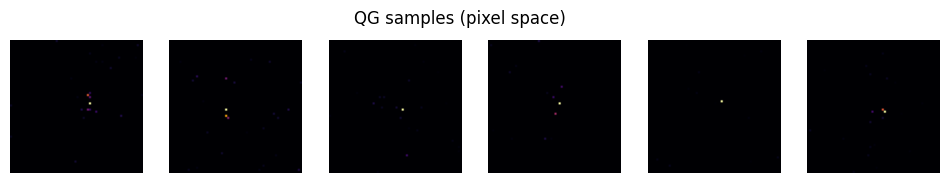

In [26]:
def show_imgs(x, n=6, title=''):
    x = x[:n].detach().cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
        axes[i].imshow(x[i,0], cmap='inferno')
        axes[i].axis('off')
    if title:
        fig.suptitle(title)
    plt.show()

show_imgs(x_px, title='QG samples (pixel space)')


## 2. Load quantum/encoded conditioning features
We load the stored patch-encoding used by `64fully_quantum.ipynb`:
- shape typically `(N, 32, 32, 4)`
We convert to channels-first and upsample to 64×64 for conditioning.


In [ ]:
# QFM / quantum encoding for conditioning
# Option A (recommended for alignment): generate q_enc directly from the same pixel tensor you train on.
# Option B (fast): load precomputed encodings from disk.

generate_q_enc = True
qenc_source = 'pixel'  # 'pixel' (uses x_px) or 'raw' (uses data_X before preprocessing)
use_entangled_patch = True

# Small 2x2-patch circuit -> 4 features (one per qubit)
dev_qenc = qml.device('default.qubit', wires=4)

@qml.qnode(dev_qenc)
def patch_circuit(phi):
    # phi: length-4 array
    for j in range(4):
        qml.RX(np.pi * float(phi[j]), wires=j)

    if use_entangled_patch:
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])
        qml.CNOT(wires=[1, 2])

    return [qml.expval(qml.PauliZ(j)) for j in range(4)]

def angle_encode_batch(x_np):
    # x_np: (N, 64, 64)
    N, H, W = x_np.shape
    out = np.zeros((N, H // 2, W // 2, 4), dtype=np.float32)

    for n in range(N):
        for i in range(0, H, 2):
            for j in range(0, W, 2):
                phi = [
                    x_np[n, i, j],
                    x_np[n, i, j + 1],
                    x_np[n, i + 1, j],
                    x_np[n, i + 1, j + 1],
                ]
                out[n, i // 2, j // 2, :] = patch_circuit(phi)
        if (n + 1) % 50 == 0:
            print(f'Encoded {n+1}/{N}', end='')

    return out

if generate_q_enc:
    if qenc_source == 'pixel':
        x_for_qenc = x_px.squeeze(1).detach().cpu().numpy()
    elif qenc_source == 'raw':
        x_for_qenc = data_X.copy()
    else:
        raise ValueError("qenc_source must be 'pixel' or 'raw'")

    q_enc_np = angle_encode_batch(x_for_qenc)
    q_enc = torch.tensor(q_enc_np, dtype=torch.float32)
else:
    enc_path = f'data/QG{QG_channel}_64x64_{num_samples}_encoded.pt'
    q_enc = torch.load(enc_path, map_location='cpu')

print('Encoded shape (NHWC):', q_enc.shape)

# Convert to (N, C, H, W)
if q_enc.ndim == 4 and q_enc.shape[-1] == 4:
    q_enc = q_enc.permute(0, 3, 1, 2).contiguous()

print('Encoded (N,C,H,W):', q_enc.shape)

def upsample_cond(q):
    # q: (N,C,32,32) -> (N,C,64,64)
    return F.interpolate(q, size=(64, 64), mode='bilinear', align_corners=False)

Encoded 50/1000

## 3. Train/Val split + loaders


In [ ]:
train_px, val_px, train_q, val_q = train_test_split(x_px, q_enc, test_size=0.2, random_state=42, shuffle=True)
train_loader = DataLoader(TensorDataset(train_px, train_q), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(val_px, val_q), batch_size=64, shuffle=False)
print('Train:', train_px.shape, train_q.shape)

Train: torch.Size([800, 1, 64, 64]) torch.Size([800, 4, 32, 32])


## 4. Diffusion utilities (DDPM-style, epsilon prediction)


In [ ]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, timesteps)

T = 200
betas = linear_beta_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, x_shape):
    out = a.gather(-1, t).float()
    return out.view(-1, 1, 1, 1)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
    return sqrt_ac * x0 + sqrt_om * noise

def predict_x0_from_noise(x_t, t, eps):
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x_t.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    return (x_t - sqrt_om * eps) / sqrt_ac


## 5. Models
We train:
- a **pixel baseline** denoiser `p(eps | x_t, t)`
- a **QFM-conditioned** denoiser `p(eps | x_t, qfm(x0), t)`

Both are small time-conditional U-Nets.


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x, t_emb):
        h = self.conv(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        return h, self.pool(h)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = DoubleConv(out_ch * 2, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        x = x + self.time_proj(t_emb)[:, :, None, None]
        return x

class TimeEmbedding(nn.Module):
    def __init__(self, n_steps, time_dim):
        super().__init__()
        self.embedding = nn.Embedding(n_steps, time_dim)
        self.mlp = nn.Sequential(nn.Linear(time_dim, time_dim), nn.SiLU())
    def forward(self, t):
        return self.mlp(self.embedding(t))

class SimpleUNet(nn.Module):
    def __init__(self, in_channels, out_channels, base=64, time_dim=128, n_steps=200):
        super().__init__()
        self.time_emb = TimeEmbedding(n_steps, time_dim)
        self.down1 = Down(in_channels, base, time_dim)
        self.down2 = Down(base, base * 2, time_dim)
        self.bot = DoubleConv(base * 2, base * 4)
        self.up2 = Up(base * 4, base * 2, time_dim)
        self.up1 = Up(base * 2, base, time_dim)
        self.out = nn.Conv2d(base, out_channels, 1)
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        h1, x = self.down1(x, t_emb)
        h2, x = self.down2(x, t_emb)
        x = self.bot(x)
        x = self.up2(x, h2, t_emb)
        x = self.up1(x, h1, t_emb)
        return self.out(x)


## 6. Train baseline + conditioned models


In [ ]:
# Reproducibility
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

model_px = SimpleUNet(in_channels=1, out_channels=1, base=64, time_dim=128, n_steps=T).to(device)
model_px_qfm = SimpleUNet(in_channels=1 + q_enc.shape[1], out_channels=1, base=64, time_dim=128, n_steps=T).to(device)

opt_px = torch.optim.Adam(model_px.parameters(), lr=2e-4)
opt_q = torch.optim.Adam(model_px_qfm.parameters(), lr=2e-4)

# Fixed validation batch + fixed noise/timestep for apples-to-apples comparison across epochs
val_batch_fixed = val_px[:64].to(device)
val_cond_fixed = upsample_cond(val_q[:64].to(device))

eval_gen = torch.Generator(device=device).manual_seed(seed + 1)

def eval_eps_loss_px(model, x0, cond=None, t_val=None):
    model.eval()
    with torch.no_grad():
        if t_val is None:
            t_val = torch.full((x0.shape[0],), T // 2, device=device, dtype=torch.long)
        eps = torch.randn(x0.shape, device=device, generator=eval_gen)
        x_t = q_sample(x0, t_val, eps)
        if cond is None:
            pred = model(x_t, t_val)
        else:
            pred = model(torch.cat([x_t, cond], dim=1), t_val)
        return float(F.mse_loss(pred, eps).item())

def train_epoch_px(model, opt, loader):
    model.train()
    losses = []
    for x0, _q in loader:
        x0 = x0.to(device)
        t = torch.randint(0, T, (x0.shape[0],), device=device)
        eps = torch.randn_like(x0)
        x_t = q_sample(x0, t, eps)
        pred = model(x_t, t)
        loss = F.mse_loss(pred, eps)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return float(np.mean(losses))

def train_epoch_qfm(model, opt, loader):
    model.train()
    losses = []
    for x0, q0 in loader:
        x0 = x0.to(device)
        q0 = q0.to(device)
        q0 = upsample_cond(q0)
        t = torch.randint(0, T, (x0.shape[0],), device=device)
        eps = torch.randn_like(x0)
        x_t = q_sample(x0, t, eps)
        pred = model(torch.cat([x_t, q0], dim=1), t)
        loss = F.mse_loss(pred, eps)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return float(np.mean(losses))

# Train longer and log train/val losses
epochs = 50
train_losses_px, train_losses_q = [], []
val_losses_px, val_losses_q = [], []

for e in range(1, epochs + 1):
    l_px = train_epoch_px(model_px, opt_px, train_loader)
    l_q = train_epoch_qfm(model_px_qfm, opt_q, train_loader)

    v_px = eval_eps_loss_px(model_px, val_batch_fixed)
    v_q = eval_eps_loss_px(model_px_qfm, val_batch_fixed, cond=val_cond_fixed)

    train_losses_px.append(l_px)
    train_losses_q.append(l_q)
    val_losses_px.append(v_px)
    val_losses_q.append(v_q)

    if e == 1 or e % 5 == 0:
        print(f"Epoch {e:3d}/{epochs} | train: px={l_px:.4f} qfm-cond={l_q:.4f} | val(fixed): px={v_px:.4f} qfm-cond={v_q:.4f}")



Epoch 1: pixel loss=0.4542  qfm-cond loss=0.6032
Epoch 2: pixel loss=0.0956  qfm-cond loss=0.1296
Epoch 3: pixel loss=0.0501  qfm-cond loss=0.0906


In [ ]:
# Plot loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses_px, label='train px')
plt.plot(train_losses_q, label='train qfm-cond')
plt.title('Training Loss (MSE eps)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(val_losses_px, label='val px (fixed batch)')
plt.plot(val_losses_q, label='val qfm-cond (fixed batch)')
plt.title('Validation Loss (fixed batch/seed)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()



## 7. Sampling
- Baseline: unconditional sampling in pixel space.
- QFM-conditioned: sampling conditioned on **existing** QFM features (from val set).

For fully unconditional hybrid generation later, we’d need a separate model to generate QFM features.


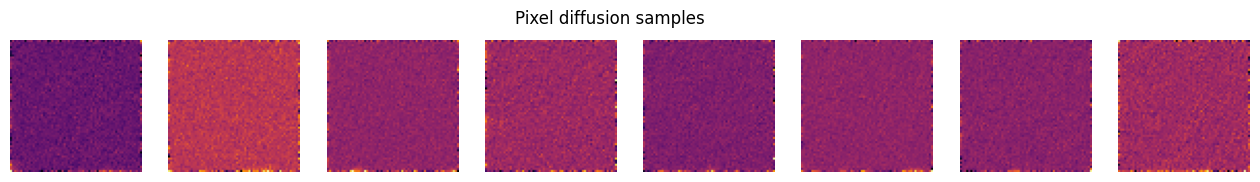

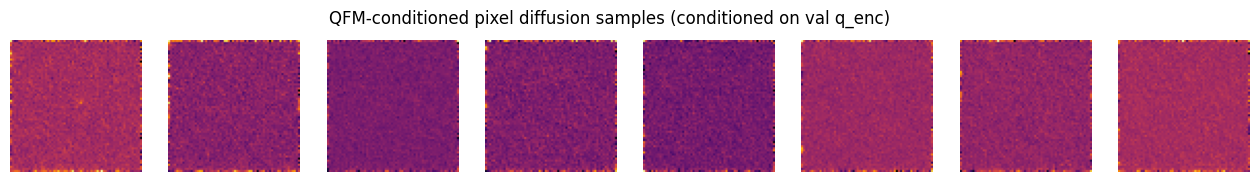

In [ ]:
@torch.no_grad()
def p_sample(model, x, t, cond=None):
    betas_t = extract(betas, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)

    if cond is None:
        eps = model(x, t)
    else:
        eps = model(torch.cat([x, cond], dim=1), t)

    model_mean = sqrt_recip_alphas_t * (x - betas_t * eps / sqrt_om)
    if (t == 0).all():
        return model_mean
    noise = torch.randn_like(x)
    var = extract(posterior_variance, t, x.shape)
    return model_mean + torch.sqrt(var) * noise

@torch.no_grad()
def p_sample_loop(model, n, cond=None):
    x = torch.randn((n, 1, 64, 64), device=device)
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, cond=cond)
    return x

# Unconditional pixel samples
samples_px = p_sample_loop(model_px, n=8)
show_imgs(samples_px, n=8, title='Pixel diffusion samples')

# Conditional samples using q_enc from validation set
q_cond = upsample_cond(val_q[:8].to(device))
samples_q = p_sample_loop(model_px_qfm, n=8, cond=q_cond)
show_imgs(samples_q, n=8, title='QFM-conditioned pixel diffusion samples (conditioned on val q_enc)')


## 8. One-step reconstruction + numeric comparison
We do a quick mid-timestep reconstruction test and compute MSE/SSIM/Wasserstein.
(FID-like on raw pixels is expensive at 64×64, so we skip it here.)


MSE:   Pixel=0.007432  QFM-Cond=0.012083
SSIM:  Pixel=0.5846  QFM-Cond=0.5084
Wass:  Pixel=0.036447  QFM-Cond=0.043825


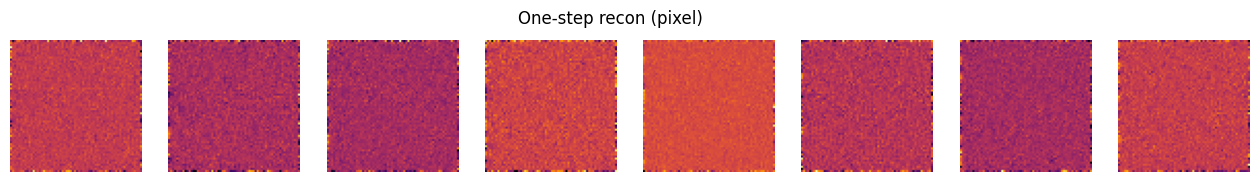

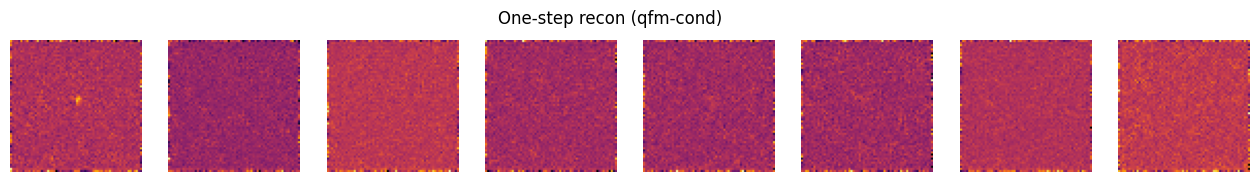

In [ ]:
@torch.no_grad()
def one_step_recon(model, x0, cond=None, t_val=None, gen=None):
    if t_val is None:
        t_val = torch.full((x0.shape[0],), T // 2, device=device, dtype=torch.long)
    if gen is None:
        gen = torch.Generator(device=device).manual_seed(seed + 2)
    eps = torch.randn(x0.shape, device=device, generator=gen)
    x_t = q_sample(x0, t_val, eps)
    if cond is None:
        pred_eps = model(x_t, t_val)
    else:
        pred_eps = model(torch.cat([x_t, cond], dim=1), t_val)
    x0_hat = predict_x0_from_noise(x_t, t_val, pred_eps)
    return x0_hat

val_batch = val_batch_fixed
val_cond = val_cond_fixed

rec_px = one_step_recon(model_px, val_batch)
rec_q = one_step_recon(model_px_qfm, val_batch, cond=val_cond)

def npify(x):
    return x.detach().cpu().numpy().squeeze(1)

real = npify(val_batch)
r_px = npify(rec_px)
r_q = npify(rec_q)

# clamp for metrics
real = np.clip(real, -1.0, 1.0)
r_px = np.clip(r_px, -1.0, 1.0)
r_q = np.clip(r_q, -1.0, 1.0)

def mean_ssim(a, b):
    return float(np.mean([ssim(a[i], b[i], data_range=2.0) for i in range(a.shape[0])]))

def mean_wass(a, b):
    # per-image 1D Wasserstein on flattened pixels
    from scipy.stats import wasserstein_distance
    return float(np.mean([wasserstein_distance(a[i].ravel(), b[i].ravel()) for i in range(a.shape[0])]))

mse_px = float(np.mean((r_px - real) ** 2))
mse_q = float(np.mean((r_q - real) ** 2))
ssim_px = mean_ssim(real, r_px)
ssim_q = mean_ssim(real, r_q)
wass_px = mean_wass(real, r_px)
wass_q = mean_wass(real, r_q)

print(f'MSE:   Pixel={mse_px:.6f}  QFM-Cond={mse_q:.6f}')
print(f'SSIM:  Pixel={ssim_px:.4f}  QFM-Cond={ssim_q:.4f}')
print(f'Wass:  Pixel={wass_px:.6f}  QFM-Cond={wass_q:.6f}')

show_imgs(rec_px, n=8, title='One-step recon (pixel)')